<a href="https://colab.research.google.com/github/ayyucedemirbas/quality_control/blob/main/mscic_QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 20.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of louvain to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 90.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 105.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 25.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 51.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 369.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 99.9 MB/s eta 0:00:00
  Created wheel for l

In [2]:
import os
import warnings
import numpy as np
import pandas as pd


from scAnalysis import (
    sc_io,
    preprocessing,
    quality_control,
    cell_cycle,
    dimensionality,
    visualization
)


warnings.filterwarnings("ignore")

In [3]:
os.makedirs("output_qc_report", exist_ok=True)

In [4]:
local_h5ad_path = "/content/drive/MyDrive/resources/grn_benchmark/inference_data/MSCIC_rna.h5ad"
data = sc_io.read_h5ad(local_h5ad_path)
data.var.index = sc_io._make_unique(data.var.index.values)

IO: Reading H5AD from '/content/drive/MyDrive/resources/grn_benchmark/inference_data/MSCIC_rna.h5ad' ...
IO: Loaded 29,284 cells × 13,431 genes.


Saved → output_qc_report/1_QC_Violins_Before_Filter.png


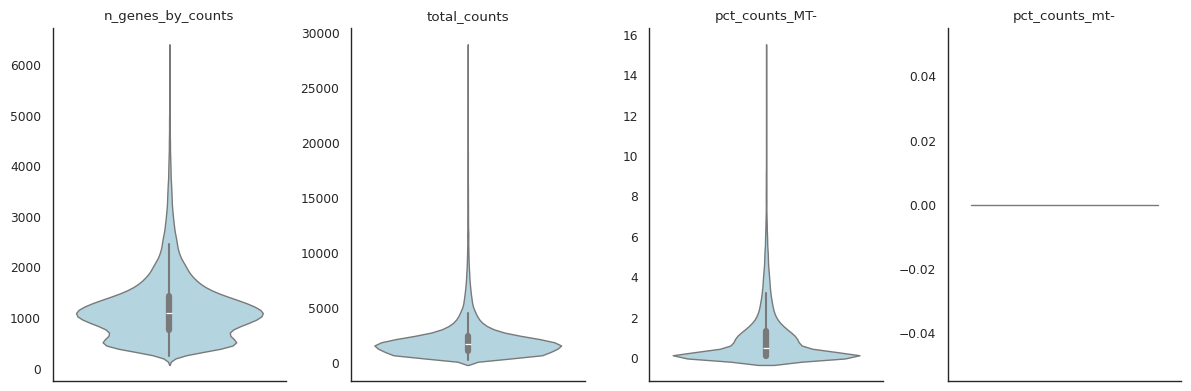

In [5]:
preprocessing.calculate_qc_metrics(data, qc_vars=["MT-", "mt-"])

visualization.plot_qc_violin(
    data,
    save="output_qc_report/1_QC_Violins_Before_Filter.png"
)

In [6]:
quality_control.scrublet(data, verbose=False)
data = quality_control.filter_doublets(data, use_prediction=True)


data = preprocessing.filter_cells(data, min_genes=200, max_pct_mito=15.0)
data = preprocessing.filter_genes(data, min_cells=3)

preprocessing.normalize_total(data, target_sum=1e4)
preprocessing.log1p(data)

Removing 1623 doublets, keeping 27661 cells
filter_cells: keeping 27,659 / 27,661 cells.
filter_genes: keeping 13,431 / 13,431 genes.


In [7]:
print(f"Total cells before filtering: {data.n_obs}")
print(f"Detected Doublets: {data.obs['predicted_doublet'].sum()} cells")
print(f"Mean Genes per Cell: {data.obs['n_genes_by_counts'].mean():.0f}")
print(f"Mean MT Percentage: {data.obs['pct_counts_MT-'].mean():.2f}%")
#print(data.obs['phase'].value_counts())

Total cells before filtering: 27659
Detected Doublets: 0 cells
Mean Genes per Cell: 1162
Mean MT Percentage: 0.99%


In [8]:
cell_cycle.score_cell_cycle(data, organism="human")
preprocessing.highly_variable_genes(data, n_top_genes=2000)

HVG: identified 2,000 highly variable genes.


In [9]:
hvg_mask = data.var["highly_variable"].values
data_hvg = data[:, hvg_mask].copy()

In [10]:
#before
data_before = data_hvg.copy()

In [11]:
preprocessing.scale(data_before, max_value=10)
dimensionality.run_pca(data_before, n_components=30)
dimensionality.neighbors(data_before, n_neighbors=15, n_pcs=30)
dimensionality.run_umap(data_before, min_dist=0.3)

PCA: using 2,000 HVGs.
PCA: computed 30 components (17.0% variance explained).
Neighbors: k=15, metric='euclidean' …
Neighbors: graph built (27,659 cells).
UMAP: min_dist=0.3, n_components=2 …


SingleCellDataset object with n_obs × n_vars = 27659 × 2000
    obs: donor_id, cell_type_orig, cell_type, site, donor_age, donor_gender, perturbation, n_genes_by_counts, total_counts, pct_counts_MT-, pct_counts_mt-, doublet_score, predicted_doublet, S_score, G2M_score, phase
    var: gene_id, n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id, split, pca, neighbors
    obsm: X_pca, X_umap
    varm: PCs
    Memory (X): 211.02 MB

In [12]:
visualization.plot_umap(
    data_before,
    color="phase",
    title="UMAP Before CC Regression",
    save="output_qc_report/2_UMAP_Before_CC_Regression.png"
)

Saved → output_qc_report/2_UMAP_Before_CC_Regression.png


<Axes: title={'center': 'UMAP Before CC Regression'}, xlabel='X_umap 1', ylabel='X_umap 2'>

In [13]:
del data_before

In [14]:
#after
cell_cycle.regress_out_cell_cycle(data_hvg, difference_only=False)

preprocessing.scale(data_hvg, max_value=10)
dimensionality.run_pca(data_hvg, n_components=30)
dimensionality.neighbors(data_hvg, n_neighbors=15, n_pcs=30)
dimensionality.run_umap(data_hvg, min_dist=0.3)


PCA: using 2,000 HVGs.
PCA: computed 30 components (15.4% variance explained).
Neighbors: k=15, metric='euclidean' …
Neighbors: graph built (27,659 cells).
UMAP: min_dist=0.3, n_components=2 …


SingleCellDataset object with n_obs × n_vars = 27659 × 2000
    obs: donor_id, cell_type_orig, cell_type, site, donor_age, donor_gender, perturbation, n_genes_by_counts, total_counts, pct_counts_MT-, pct_counts_mt-, doublet_score, predicted_doublet, S_score, G2M_score, phase
    var: gene_id, n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id, split, pca, neighbors
    obsm: X_pca, X_umap
    varm: PCs
    Memory (X): 211.02 MB

In [15]:
visualization.plot_umap(
    data_hvg,
    color="phase",
    title="UMAP After CC Regression",
    save="output_qc_report/3_UMAP_After_CC_Regression.png"
)

Saved → output_qc_report/3_UMAP_After_CC_Regression.png


<Axes: title={'center': 'UMAP After CC Regression'}, xlabel='X_umap 1', ylabel='X_umap 2'>

In [16]:
active_data = data_hvg if 'data_hvg' in locals() else data
print(active_data.obs['phase'].value_counts().to_string())

phase
G1     18067
S       5626
G2M        0
